# Trefoil-knot obstacle peak velocity (numerical L2 max)

Computes the exact $L_2$ peak of $\|\dot{\mathbf{c}}_k(t)\|_2$ for the dynamic-obstacle trefoil-knot
parameterization used in the SANDO dynamic benchmark (Section IX-C):

$$\mathbf{c}_k(t) = (x_0, y_0, z_0) + \left(
    \tfrac{s_x}{6}(\sin\tau + 2\sin 2\tau),\;
    \tfrac{s_y}{5}(\cos\tau - 2\cos 2\tau),\;
    -\tfrac{s_z}{2}\sin 3\tau
\right), \quad \tau = \frac{t + \mathrm{offset}}{\mathrm{slower}}.$$

Per-axis velocities (closed-form from chain rule):
$$\dot{c}^x_k = \frac{s_x}{6\,\mathrm{slower}}(\cos\tau + 4\cos 2\tau), \quad
  \dot{c}^y_k = \frac{s_y}{5\,\mathrm{slower}}(-\sin\tau + 4\sin 2\tau), \quad
  \dot{c}^z_k = -\frac{3 s_z}{2\,\mathrm{slower}}\cos 3\tau.$$

The relevant quantity for Theorem 1 is $\max_t \|\dot{\mathbf{c}}_k(t)\|_2$, which requires *joint* maximization over $\tau$ rather than per-axis maximization. We compute it by dense $\tau$ sweep.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

np.set_printoptions(precision=4, suppress=True)


## 1. Closed-form velocity functions

In [6]:
def velocity_components(tau, sx, sy, sz, slower):
    """Return (vx, vy, vz) at parameter tau given trefoil scales and time factor."""
    vx = (sx / (6.0 * slower)) * (np.cos(tau) + 4.0 * np.cos(2.0 * tau))
    vy = (sy / (5.0 * slower)) * (-np.sin(tau) + 4.0 * np.sin(2.0 * tau))
    vz = -(3.0 * sz / (2.0 * slower)) * np.cos(3.0 * tau)
    return vx, vy, vz


def speed_l2(tau, sx, sy, sz, slower):
    vx, vy, vz = velocity_components(tau, sx, sy, sz, slower)
    return np.sqrt(vx ** 2 + vy ** 2 + vz ** 2)


def peak_speed(sx, sy, sz, slower, n=200_000):
    """Dense sweep over tau in [0, 2*pi]; return (peak_speed, tau_argmax)."""
    tau = np.linspace(0.0, 2.0 * np.pi, n)
    s = speed_l2(tau, sx, sy, sz, slower)
    idx = int(np.argmax(s))
    return float(s[idx]), float(tau[idx])


def peak_speed_refined(sx, sy, sz, slower, n=200_000):
    """Coarse dense sweep, then refine the argmax with a local optimizer."""
    s_max_coarse, tau0 = peak_speed(sx, sy, sz, slower, n=n)
    # Refine within a small neighborhood of tau0
    dtau = 2.0 * np.pi / n
    res = minimize_scalar(
        lambda t: -speed_l2(t, sx, sy, sz, slower),
        bounds=(tau0 - 5 * dtau, tau0 + 5 * dtau),
        method='bounded',
        options={'xatol': 1e-12},
    )
    return float(-res.fun), float(res.x)


## 2. Worst-case parameters

The simulation samples $s_x, s_y, s_z \sim \mathcal{U}[2, 4]$ and $\mathrm{slower} \sim \mathcal{U}[4, 6]$. The peak speed is maximized by maxing the numerator (large $s$) and minimizing the denominator (small slower).

In [7]:
# Worst-case parameter combination across the sampling distribution
sx, sy, sz, slower = 4.0, 4.0, 4.0, 4.0

peak, tau_star = peak_speed_refined(sx, sy, sz, slower)
vx, vy, vz = velocity_components(tau_star, sx, sy, sz, slower)

print(f'Worst-case parameters: sx=sy=sz={sx}, slower={slower}')
print(f'  Peak L2 speed:        {peak:.4f} m/s  at tau* = {tau_star:.4f} rad')
print(f'  Velocity components:  vx={vx:.4f}, vy={vy:.4f}, vz={vz:.4f}')
print()
print(f'  Comparison vs analytic bounds:')
print(f'    Per-axis L_inf maxes:')
print(f'      |vx|_max (analytic) = 5*sx / (6*slower)       = {5*sx/(6*slower):.4f} m/s')
print(f'      |vy|_max (analytic) ~ 4.72*sy / (5*slower)    = {4.72*sy/(5*slower):.4f} m/s')
print(f'      |vz|_max (analytic) = 1.5*sz / slower         = {1.5*sz/slower:.4f} m/s')
print(f'    Conservative L2 bound (sqrt sum of squares):    {np.sqrt((5*sx/(6*slower))**2 + (4.72*sy/(5*slower))**2 + (1.5*sz/slower)**2):.4f} m/s')
print(f'    Exact L2 peak (this notebook):                   {peak:.4f} m/s')


Worst-case parameters: sx=sy=sz=4.0, slower=4.0
  Peak L2 speed:        1.7819 m/s  at tau* = 2.1029 rad
  Velocity components:  vx=-0.4081, vy=-0.8718, vz=-1.4995

  Comparison vs analytic bounds:
    Per-axis L_inf maxes:
      |vx|_max (analytic) = 5*sx / (6*slower)       = 0.8333 m/s
      |vy|_max (analytic) ~ 4.72*sy / (5*slower)    = 0.9440 m/s
      |vz|_max (analytic) = 1.5*sz / slower         = 1.5000 m/s
    Conservative L2 bound (sqrt sum of squares):    1.9585 m/s
    Exact L2 peak (this notebook):                   1.7819 m/s


## 3. Velocity profile over one period

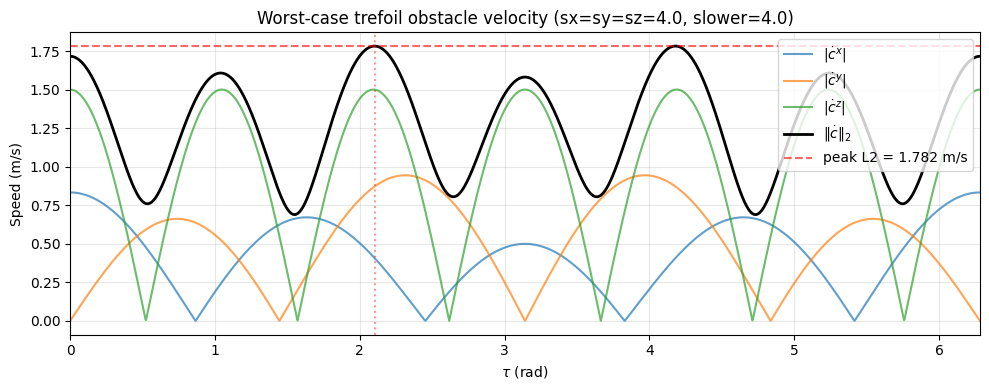

In [9]:
tau = np.linspace(0.0, 2.0 * np.pi, 2_000)
vx, vy, vz = velocity_components(tau, sx, sy, sz, slower)
v_l2 = np.sqrt(vx ** 2 + vy ** 2 + vz ** 2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(tau, np.abs(vx), label=r'$|\dot c^x|$', alpha=0.7)
ax.plot(tau, np.abs(vy), label=r'$|\dot c^y|$', alpha=0.7)
ax.plot(tau, np.abs(vz), label=r'$|\dot c^z|$', alpha=0.7)
ax.plot(tau, v_l2, label=r'$\|\dot{c}\|_2$', linewidth=2.0, color='black')
ax.axhline(peak, linestyle='--', color='red', alpha=0.6, label=f'peak L2 = {peak:.3f} m/s')
ax.axvline(tau_star, linestyle=':', color='red', alpha=0.4)
ax.set_xlabel(r'$\tau$ (rad)')
ax.set_ylabel('Speed (m/s)')
ax.set_title(f'Worst-case trefoil obstacle velocity (sx=sy=sz={sx}, slower={slower})')
ax.set_xlim(0, 2 * np.pi)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Typical parameters (means of the sampling distribution)

In [10]:
sx_t, sy_t, sz_t, slower_t = 3.0, 3.0, 3.0, 5.0
peak_t, tau_t = peak_speed_refined(sx_t, sy_t, sz_t, slower_t)
print(f'Typical parameters: sx=sy=sz={sx_t}, slower={slower_t}')
print(f'  Peak L2 speed:    {peak_t:.4f} m/s  at tau* = {tau_t:.4f} rad')
print(f'  Conservative L2 bound: {np.sqrt((5*sx_t/(6*slower_t))**2 + (4.72*sy_t/(5*slower_t))**2 + (1.5*sz_t/slower_t)**2):.4f} m/s')


Typical parameters: sx=sy=sz=3.0, slower=5.0
  Peak L2 speed:    1.0691 m/s  at tau* = 2.1029 rad
  Conservative L2 bound: 1.1751 m/s


## 5. Monte-Carlo over the sampling distribution

Sample many obstacle parameter draws from the actual distribution
($s_x, s_y, s_z \sim \mathcal{U}[2, 4]$, $\mathrm{slower} \sim \mathcal{U}[4, 6]$),
compute the peak L2 speed per draw, and report the distribution. The maximum across all draws is the empirical worst case across the sampling distribution.

In [11]:
rng = np.random.default_rng(0)
N = 10_000
sx_draws = rng.uniform(2.0, 4.0, N)
sy_draws = rng.uniform(2.0, 4.0, N)
sz_draws = rng.uniform(2.0, 4.0, N)
slower_draws = rng.uniform(4.0, 6.0, N)

# Use a fixed tau grid for all draws to avoid per-draw refinement (much faster)
tau = np.linspace(0.0, 2.0 * np.pi, 20_000)
peaks = np.empty(N)
for i in range(N):
    vx, vy, vz = velocity_components(tau, sx_draws[i], sy_draws[i], sz_draws[i], slower_draws[i])
    peaks[i] = np.max(np.sqrt(vx ** 2 + vy ** 2 + vz ** 2))

print(f'Monte-Carlo over N={N} draws from the simulation distribution:')
print(f'  Empirical max peak L2:    {peaks.max():.4f} m/s')
print(f'  99th percentile peak L2:  {np.percentile(peaks, 99):.4f} m/s')
print(f'  95th percentile peak L2:  {np.percentile(peaks, 95):.4f} m/s')
print(f'  Median peak L2:           {np.median(peaks):.4f} m/s')
print(f'  Mean peak L2:             {peaks.mean():.4f} m/s')


Monte-Carlo over N=10000 draws from the simulation distribution:
  Empirical max peak L2:    1.7458 m/s
  99th percentile peak L2:  1.5909 m/s
  95th percentile peak L2:  1.4661 m/s
  Median peak L2:           1.0826 m/s
  Mean peak L2:             1.1013 m/s


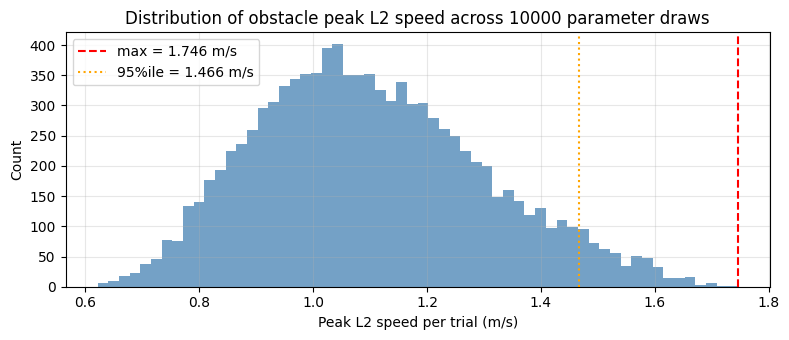

In [12]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(peaks, bins=60, color='steelblue', alpha=0.75)
ax.axvline(peaks.max(), linestyle='--', color='red', label=f'max = {peaks.max():.3f} m/s')
ax.axvline(np.percentile(peaks, 95), linestyle=':', color='orange', label=f'95%ile = {np.percentile(peaks, 95):.3f} m/s')
ax.set_xlabel('Peak L2 speed per trial (m/s)')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of obstacle peak L2 speed across {N} parameter draws')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6. Summary for R4.10 / v_max^obs decision

The relevant number for setting $v_{\max}^{\mathrm{obs}}$ to satisfy Assumption 1 ($\|\dot{\mathbf{c}}_k(t)\|_2 \le v_{\max}^{\mathrm{obs}}$) over the whole sampling distribution is the **empirical max peak L2** from Section 5 above. Setting $v_{\max}^{\mathrm{obs}}$ to this value (or slightly above) makes Theorem 1 apply as written.

Next steps (if you want to switch to this configuration):
1. Adopt $v_{\max}^{\mathrm{obs}} = \lceil \text{empirical max} \rceil$ (or with a small safety margin).
2. Rerun the dynamic-w/GT benchmark (Hard difficulty first — it's the bottleneck) and check whether the corridor inflation $r_n = v_{\max}^{\mathrm{obs}}(n{+}1)\,dt + \epsilon$ still permits feasible MIQPs.
3. If yes, switch entirely. If no, report both configurations and the empirical trade-off.